# Extraction Reliability: Independent Second Coding of the NDE Extraction

Agreement between the GPT-5.2 structured extraction and a blind second coder · **Created:** 2026-10-06

---

## Why this notebook exists

Every number in `projects/nde` is a GPT-5.2 code of a narrative. Earlier reports listed "no human validation" as a limitation. That framing is wrong in one respect: human coders are not a gold standard for these variables. Human coders disagree with each other, drift over time, and bring their own expectations. What the analyses need is an estimate of **measurement reliability**: how far the codes would change if an independent, competent coder read the same text with the same codebook.

Reliability can be measured without assuming either coder is right. Agreement statistics (Cohen's κ, Gwet's AC1) measure reproducibility. Low agreement shows that a variable is not measured precisely enough to support fine distinctions, whoever is "correct". High agreement bounds the measurement error that could produce or hide an effect.

## Design

| Element | Choice |
|---|---|
| First coder | GPT-5.2 structured extraction (the data used by notebooks 01–07) |
| Second coder | Claude, coding blind: it saw only the narrative packet (dataset, title, date, narrative), the same text GPT-5.2 received. It never saw any extracted value |
| Codebook | The `Field(description=...)` texts and enum values of `models/questionnaire.py`, the same instructions GPT-5.2 received |
| Set A | 100 accounts drawn at random from all 6,751 (seed 20261006); 15 fields covering light, beings, guidance, communication, life review, tunnel, boundary, return, mission, reality, religion |
| Set B | Life-review judgment (`occurrence`, `judgment_source`, `judgment_intensity`) for 40 accounts drawn at random from the 428 rated life reviews (seed 20261007), plus every account GPT-5.2 rated `harsh_condemning` (census of 6). 44 accounts in total (2 harsh accounts were already in the random 40) |
| Statistics | % agreement; Cohen's κ; Gwet's AC1 (robust to low prevalence); 2,000-case bootstrap 95% CIs; exact McNemar test of prevalence bias; linear-weighted κ for the ordinal judgment scale |

**Limitations of the design.** The second coder is a different model family, but it is still a language model, and it knew the research framework. If framework knowledge biased it, the bias would favour framework-congruent codes (for example, gentler judgment). Part IV shows the disagreements on judgment run the other way. The coder read each narrative once; there is no third coder to adjudicate. Where the schema text is ambiguous, the second coder used the conventions listed in `validation/README.md`. These are reported, not hidden, because several disagreements come from codebook ambiguity rather than coder error.

## Part I: Samples and codes

In [1]:
import sys, json, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu, wilcoxon
from statsmodels.stats.multitest import multipletests

NDE_ROOT = Path.cwd().parent
sys.path.insert(0, str(NDE_ROOT / "scripts"))
import nde_dataset as nd  # verified loader: schema-checked fields, dedup, narrative word counts

OUTPUT_DIR = NDE_ROOT / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 8)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

df = nd.load_frame()          # one row per NDE; exact duplicate narratives removed
N = len(df)
print(f"Loaded {N:,} records (after removing exact duplicate narratives)")
print(df["dataset"].value_counts().to_string())

from sklearn.metrics import cohen_kappa_score
from scipy.stats import binomtest
from sklearn.feature_extraction.text import TfidfVectorizer

VALIDATION_DIR = NDE_ROOT / "validation"
codes = pd.DataFrame([json.loads(line) for line in (VALIDATION_DIR / "second_coder_codes.jsonl").read_text().splitlines()])
codes = codes.set_index("key")

# Re-draw both samples with the recorded seeds and check they are exactly the coded accounts.
rng = np.random.default_rng(20261006)
set_a = sorted(rng.choice(df["file"].values, size=100, replace=False).tolist())
rated = df[df["life_review"] & nd.isin(df, "judgment_intensity", ["loving_gentle", "neutral", "uncomfortable", "harsh_condemning"])]
rng_b = np.random.default_rng(20261007)
random_b = sorted(rng_b.choice(rated["file"].values, size=40, replace=False).tolist())
harsh_census = sorted(rated.loc[rated["judgment_intensity"] == "harsh_condemning", "file"])
set_b = sorted(set(random_b) | set(harsh_census))

assert sorted(codes.index[codes["sets"].str.contains("A")]) == set_a
assert sorted(codes.index[codes["sets"].str.contains("B")]) == set_b
print(f"Set A: {len(set_a)} accounts | Set B: {len(set_b)} accounts ({len(random_b)} random + {len(harsh_census)} harsh census, overlap {len(set(random_b) & set(harsh_census))})")
print(f"Accounts in both sets: {len(set(set_a) & set(set_b))}; total coded: {len(codes)}")
print(f"Rated life reviews in the population: {len(rated)}")

g_all = df.set_index("file")
print(f"Set A median narrative length: {g_all.loc[set_a, 'word_count'].median():.0f} words (all records: {df['word_count'].median():.0f})")

Loaded 6,751 records (after removing exact duplicate narratives)
dataset
nderf    5659
iands    1092
Set A: 100 accounts | Set B: 44 accounts (40 random + 6 harsh census, overlap 2)
Accounts in both sets: 3; total coded: 141
Rated life reviews in the population: 428
Set A median narrative length: 704 words (all records: 683)


### Mapping the two coders onto common variables

The second coder recorded whole-account binary flags for beings and functions and the schema's own categories for single-choice fields. GPT-5.2 fields are mapped as the analysis notebooks use them: `nd.YES` for `yes_explicit`/`implied`, any of brief/extensive for life review, any boundary type for "boundary". `being_identifications` is defined in the schema as beings "encountered upon arrival". The second coder flagged beings anywhere in the account, so being flags have a scope difference built in.

In [2]:
A = codes.loc[set_a]
G = g_all.loc[set_a]

def gpt_flag(frame, column, values):
    return nd.isin(frame, column, values).astype(int)

LIGHT_ANY = ["being_of_light", "brilliant_light", "presence_without_visual"]
BINARY = {
    # label: (GPT series, second-coder series)
    "Being of light": (gpt_flag(G, "light_encounter", ["being_of_light"]), (A["light"] == "being_of_light").astype(int)),
    "Any light encounter": (gpt_flag(G, "light_encounter", LIGHT_ANY), A["light"].isin(LIGHT_ANY).astype(int)),
    "Unknown presence": (gpt_flag(G, "being_identifications", ["unknown_presence"]), A["unknown"].astype(int)),
    "God or Jesus": (gpt_flag(G, "being_identifications", ["god", "jesus"]), A["godjesus"].astype(int)),
    "Deceased relatives": ((nd.isin(G, "deceased_relatives", nd.DECEASED_YES) | nd.has(G, "being_identifications", "deceased_relative_guide")).astype(int), A["relatives"].astype(int)),
    "Guidance received": (gpt_flag(G, "guidance_received", ["yes"]), (A["guidance"] == "yes").astype(int)),
    "Teaching": (gpt_flag(G, "guidance_types", ["teaching"]), A["teaching"].astype(int)),
    "Telepathic communication": (gpt_flag(G, "communication_modes", ["telepathic"]), A["telepathic"].astype(int)),
    "Life review": (gpt_flag(G, "occurrence", nd.LIFE_REVIEW_YES), A["lr"].isin(nd.LIFE_REVIEW_YES).astype(int)),
    "Tunnel": (gpt_flag(G, "passage_type", ["tunnel"]), A["tunnel"].astype(int)),
    "Boundary (any type)": (gpt_flag(G, "boundary_encounter", nd.BOUNDARY_YES), A["boundary"].isin(nd.BOUNDARY_YES).astype(int)),
    "Return decided by a being": (gpt_flag(G, "return_agency", ["external_being"]), (A["agency"] == "external_being").astype(int)),
    "Mission commissioned": (gpt_flag(G, "mission_commissioned", nd.YES), A["mission"].astype(int)),
    "Mission commissioned (explicit only)": (gpt_flag(G, "mission_commissioned", ["yes_explicit"]), A["mission"].astype(int)),
    "Earthly-mission return reason": (gpt_flag(G, "return_reasons", ["earthly_mission"]), A["em"].astype(int)),
    "More real than earthly life": (gpt_flag(G, "comparative_reality", ["more_real_explicit", "more_real_implied"]), A["morereal"].astype(int)),
}
CATEGORICAL = {
    "Light encounter (5 categories)": (G["light_encounter"], A["light"]),
    "Return agency (5 categories)": (G["return_agency"], A["agency"]),
    "Religious background (9 categories)": (G["religious_background"], A["religion"]),
}
print("Fields compared:", len(BINARY), "binary +", len(CATEGORICAL), "categorical")

Fields compared: 16 binary + 3 categorical


## Part II: Agreement on 100 random accounts (set A)

In [3]:
def gwet_ac1(a, b, categories=None):
    a, b = np.asarray(a), np.asarray(b)
    cats = sorted(set(a) | set(b)) if categories is None else categories
    q = max(len(cats), 2)
    pa = np.mean(a == b)
    pi = np.array([(np.sum(a == c) + np.sum(b == c)) / (2 * len(a)) for c in cats])
    pe = np.sum(pi * (1 - pi)) / (q - 1)
    return (pa - pe) / (1 - pe)

def kappa(a, b, weights=None):
    a, b = np.asarray(a).astype(str), np.asarray(b).astype(str)
    if len(set(a) | set(b)) < 2:
        return np.nan
    if weights:
        return cohen_kappa_score(a, b, weights=weights, labels=sorted(set(a) | set(b), key=ORDER.get))
    return cohen_kappa_score(a, b)

def boot_ci(a, b, stat, n_boot=2000, seed=0, **kw):
    a, b = np.asarray(a), np.asarray(b)
    rng = np.random.default_rng(seed)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(a), len(a))
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            v = stat(a[idx], b[idx], **kw)
        if np.isfinite(v):
            vals.append(v)
    return np.percentile(vals, [2.5, 97.5])

ORDER = {"loving_gentle": 0, "neutral": 1, "uncomfortable": 2, "harsh_condemning": 3}

rows = []
for label, (g, s) in BINARY.items():
    g, s = g.values, s.values
    b_only, s_only = int(((g == 1) & (s == 0)).sum()), int(((g == 0) & (s == 1)).sum())
    k = kappa(g, s)
    lo, hi = boot_ci(g, s, kappa)
    mcn = binomtest(b_only, b_only + s_only, 0.5).pvalue if b_only + s_only else 1.0
    rows.append({"field": label, "GPT +": int(g.sum()), "coder +": int(s.sum()), "both +": int(((g == 1) & (s == 1)).sum()),
                 "GPT only": b_only, "coder only": s_only, "agree %": 100 * np.mean(g == s),
                 "kappa": k, "kappa lo": lo, "kappa hi": hi, "AC1": gwet_ac1(g, s), "McNemar p": mcn})
for label, (g, s) in CATEGORICAL.items():
    g, s = g.values.astype(str), s.values.astype(str)
    k = kappa(g, s)
    lo, hi = boot_ci(g, s, kappa)
    rows.append({"field": label, "agree %": 100 * np.mean(g == s), "kappa": k, "kappa lo": lo, "kappa hi": hi, "AC1": gwet_ac1(g, s)})
agree = pd.DataFrame(rows).set_index("field")
agree["McNemar p (Holm)"] = np.nan
m = agree["McNemar p"].notna()
agree.loc[m, "McNemar p (Holm)"] = multipletests(agree.loc[m, "McNemar p"], method="holm")[1]

def band(k):
    return "almost perfect" if k > 0.8 else "substantial" if k > 0.6 else "moderate" if k > 0.4 else "fair" if k > 0.2 else "slight"
agree["band"] = agree["kappa"].map(band)
with pd.option_context("display.float_format", "{:.2f}".format):
    print(agree.drop(columns=["McNemar p"]).to_string())
print()
print("Median kappa (binary fields, excl. explicit-only duplicate):",
      f"{agree.loc[[k for k in BINARY if 'explicit only' not in k], 'kappa'].median():.2f}")
print("Fields with kappa > 0.80:", ", ".join(agree.index[agree.kappa > 0.8]))
print("Fields with kappa <= 0.60:", ", ".join(agree.index[agree.kappa <= 0.6]))

                                      GPT +  coder +  both +  GPT only  coder only  agree %  kappa  kappa lo  kappa hi  AC1  McNemar p (Holm)            band
field                                                                                                                                                        
Being of light                        14.00    13.00   12.00      2.00        1.00    97.00   0.87      0.70      1.00 0.96              1.00  almost perfect
Any light encounter                   62.00    63.00   59.00      3.00        4.00    93.00   0.85      0.73      0.95 0.87              1.00  almost perfect
Unknown presence                      13.00    21.00    9.00      4.00       12.00    84.00   0.44      0.20      0.66 0.78              0.94        moderate
God or Jesus                          14.00    19.00   14.00      0.00        5.00    95.00   0.82      0.65      0.96 0.93              0.94  almost perfect
Deceased relatives                    22.00    21.00

### Findings — set A

**Finding A1: most variables are reproducible.** Across the 15 binary variables (the explicit-only mission variant is a sensitivity check and is excluded), the median κ is **0.83**. Nine exceed 0.80, the conventional threshold for "almost perfect" agreement:

| κ > 0.80 | κ 0.61–0.80 | κ ≤ 0.60 |
|---|---|---|
| tunnel 0.97, life review 0.92, telepathic communication 0.88, guidance received 0.88, being of light 0.87, deceased relatives 0.85, any light encounter 0.85, return decided by a being 0.83, God or Jesus 0.82 | boundary (any type) 0.77, earthly-mission return reason 0.75, more real than earthly life 0.74, mission commissioned 0.71, teaching 0.70 | **unknown presence 0.44** |

The multi-category fields reach κ = 0.67 (light encounter, 5 categories), 0.69 (return agency) and 0.79 (religious background, 9 categories). With n = 100 the intervals are wide: teaching, for example, has a 95% CI of 0.45–0.88. Gwet's AC1, which is not depressed by low prevalence, is 0.78–0.98 for every binary field.

**Finding A2: no prevalence bias survives correction, but four asymmetries point the same way as Part III.** GPT-5.2 codes more mission commissioning than the second coder (20 vs 12; all 8 discordant accounts are GPT-only; exact McNemar p = 0.008, Holm-adjusted p = 0.12). It also codes more "more real than earthly life" (13 vs 8; p = 0.06). It codes fewer unknown presences (13 vs 21; p = 0.08) and fewer God or Jesus encounters (14 vs 19; p = 0.06). The scope difference explains part of the God or Jesus gap: GPT-5.2's field covers beings met "upon arrival", the second coder's covers the whole account.

**What this means.** For the variables that carry most of the reported findings, the coding is reproducible at κ ≥ 0.77. These variables are light, beings, deceased relatives, telepathy, guidance, life review, tunnel, boundary presence and return agency. Random misclassification at this level weakens associations rather than creating them, so the large associations in notebooks 01–07 cannot be products of coding noise. Systematic convention differences are another matter: they can shift prevalences. Part III identifies where they do.

## Part III: Where the coders disagree

Agreement statistics say *how much* the coders differ. The pattern of disagreements says *why*, and whether the cause is coder error or an ambiguous codebook. The four weakest or most biased variables are examined in turn.

In [4]:
pd.set_option("display.max_colwidth", 110)

print("=== 1. Unknown presence: what GPT-5.2 coded when the second coder saw an unidentified being ===")
s_only = A.index[(A["unknown"] == 1) & (G["being_identifications"].apply(lambda xs: "unknown_presence" not in xs))]
print(Counter(tuple(sorted(G.loc[f, "being_identifications"])) for f in s_only))
other_or_none = sum(1 for f in s_only if set(G.loc[f, "being_identifications"]) <= {"other", "angels"} )
print(f"{len(s_only)} second-coder-only cases; GPT used only 'other'/'angels' or nothing in {other_or_none}")
g_wide = (nd.isin(G, "being_identifications", ["unknown_presence", "other"])).astype(int).values
k = kappa(g_wide, A["unknown"].astype(int).values)
print(f"GPT 'unknown_presence OR other' vs coder 'unknown presence': kappa = {k:.2f}")

print("\n=== 2. Mission commissioned: GPT-only codes ===")
m_only = A.index[(BINARY["Mission commissioned"][0] == 1) & (A["mission"] == 0)]
print(G.loc[m_only, "mission_commissioned"].value_counts().to_string())
for f in m_only:
    print(" -", G.loc[f, "mission_detail"][:150])
tab = pd.crosstab(G["mission_commissioned"], A["mission"], margins=True)
print(tab.to_string())

print("\n=== 3. Boundary type among accounts both coders call a boundary ===")
both = G["boundary_encounter"].isin(nd.BOUNDARY_YES) & A["boundary"].isin(nd.BOUNDARY_YES)
print(pd.crosstab(G.loc[both, "boundary_encounter"], A.loc[both, "boundary"]).to_string())
kb = kappa(G.loc[both, "boundary_encounter"].values, A.loc[both, "boundary"].values)
print(f"n = {both.sum()}, type agreement = {100 * np.mean(G.loc[both, 'boundary_encounter'] == A.loc[both, 'boundary']):.0f}%, kappa = {kb:.2f}")

print("\n=== 4. Light encounter: the 'no' vs 'not_mentioned' convention ===")
print(pd.crosstab(G["light_encounter"], A["light"]).to_string())
both_lr = G["occurrence"].isin(nd.LIFE_REVIEW_YES) & A["lr"].isin(nd.LIFE_REVIEW_YES)
print("\nLife-review depth where both coders see a review (rows GPT, columns coder):")
print(pd.crosstab(G.loc[both_lr, "occurrence"], A.loc[both_lr, "lr"]).to_string())

=== 1. Unknown presence: what GPT-5.2 coded when the second coder saw an unidentified being ===
Counter({('other',): 5, (): 4, ('angels', 'other'): 1, ('god',): 1, ('deceased_relative_guide', 'other'): 1})
12 second-coder-only cases; GPT used only 'other'/'angels' or nothing in 10
GPT 'unknown_presence OR other' vs coder 'unknown presence': kappa = 0.51

=== 2. Mission commissioned: GPT-only codes ===
mission_commissioned
implied    8
 - Felt a natural, genuine impulse to forgive; later guidance emphasized forgiving regardless of money/ill feelings; ongoing emphasis that 'LOVE is every
 - Stated purpose/life guidance after: love and accept everyone equally; forgive to be forgiven; share story to change others' lives; quit drugs.
 - Told/urged to love more, forgive others, avoid focusing on others' mistakes; later states he can comfort/help/guide others and emphasizes love as the 
 - Interpreted message as needing to "chill out" in life; later reports being shown in dreams that his purp

In [5]:
# Calibrating mission-commissioning prevalence to the second coder.
# Within set A, P(coder = mission | GPT category) is estimated for yes_explicit and implied (no / not_mentioned: 0 of 80).
mc = G["mission_commissioned"]
e_vals, i_vals = A.loc[mc == "yes_explicit", "mission"].values, A.loc[mc == "implied", "mission"].values
share = df["mission_commissioned"].value_counts(normalize=True)
mission_gpt = 100 * (share.get("yes_explicit", 0) + share.get("implied", 0))
mission_cal = 100 * (share.get("yes_explicit", 0) * e_vals.mean() + share.get("implied", 0) * i_vals.mean())
rng_m = np.random.default_rng(11)
cal_boot = [100 * (share.get("yes_explicit", 0) * rng_m.choice(e_vals, len(e_vals)).mean()
                   + share.get("implied", 0) * rng_m.choice(i_vals, len(i_vals)).mean()) for _ in range(5000)]
lo_m, hi_m = np.percentile(cal_boot, [2.5, 97.5])
print(f"Second coder confirms {int(e_vals.sum())}/{len(e_vals)} GPT 'yes_explicit' and {int(i_vals.sum())}/{len(i_vals)} GPT 'implied' mission codes")
print(f"Population: GPT explicit {100 * share.get('yes_explicit', 0):.1f}% + implied {100 * share.get('implied', 0):.1f}% = {mission_gpt:.1f}%")
print(f"Calibrated to the second coder: {mission_cal:.1f}% [95% CI {lo_m:.1f}-{hi_m:.1f}]")

print("\nEarthly-mission return reason (rows) x mission commissioned (columns), set A")
print("GPT-5.2:"); print(pd.crosstab(BINARY["Earthly-mission return reason"][0], BINARY["Mission commissioned"][0]).to_string())
print("Second coder:"); print(pd.crosstab(A["em"].astype(int), A["mission"].astype(int)).to_string())

Second coder confirms 7/7 GPT 'yes_explicit' and 5/13 GPT 'implied' mission codes
Population: GPT explicit 10.4% + implied 11.5% = 21.9%
Calibrated to the second coder: 14.8% [95% CI 12.2-18.4]

Earthly-mission return reason (rows) x mission commissioned (columns), set A
GPT-5.2:
mission_commissioned   0   1
return_reasons              
0                     80  14
1                      0   6
Second coder:
mission   0  1
em            
0        87  6
1         1  6


### Findings — anatomy of the disagreements

**Finding D1: "unknown presence" vs "other" is a codebook boundary, not a measurement.** The second coder flagged 12 unidentified beings that GPT-5.2 did not code as `unknown_presence`. GPT-5.2 coded 10 of them as `other`, `angels`, or no being at all. The schema does not define where "unknown presence" ends and "other" begins. Counting GPT's `other` as unknown raises κ only to 0.51. GPT-5.2 is consistent with itself on this field (test–retest κ = 0.83, Part V), so the instability is between codebook readings, not within a coder. **Consequence:** "unknown presence" is a category label chosen by the coder, not a word chosen by the experiencer. Its share of Light-Being identifications cannot bear interpretive weight, for example as evidence that experiencers prefer personal over impersonal vocabulary.

**Finding D2: GPT-5.2's "implied" mission codes are liberal.** The second coder confirmed all 7 `yes_explicit` codes but only 5 of 13 `implied` codes. The 8 unconfirmed ones are general life lessons: love more, forgive, "go, live your life well", "chill out". The schema asks whether the experiencer was "given a specific task/mission". Calibrated to the second coder, mission commissioning falls from **21.9% to 14.8%** (95% CI 12.2–18.4%). The link between an earthly-mission return reason and commissioning holds under both coders: GPT-5.2 6/6, second coder 6/7.

**Finding D3: boundary *type* is unreliable, boundary *presence* is not.** Among 36 accounts both coders treat as a boundary, the type agrees in 58% (κ = 0.34). In 11 of the 16 accounts GPT-5.2 coded `physical_barrier`, the second coder coded `verbal_limit`. These accounts contain both a barrier and a being who says "not your time". The schema has no precedence rule, and the two coders resolved the conflict differently. Analyses that compare boundary *types* depend on that unstated rule. These include the East–West report's boundary-type × return-agency association and the "verbal limit" function in notebook 07.

**Finding D4: the "no" vs "not_mentioned" convention lowers multi-category κ without affecting any analysis.** Most light-encounter disagreements are GPT-5.2 `no` against second-coder `not_mentioned` (11 accounts). Both mean absence in every analysis. The binary collapses agree at κ = 0.85–0.87. Life-review *depth* is less reliable than life-review *presence*: GPT-5.2's `extensive` was `brief` for the second coder in 3 of 6 set-A reviews and 6 of 22 set-B reviews.

## Part IV: Life-review judgment (set B)

The "Judgment character" result (loving:harsh about 36:1) rests on two fields: `judgment_source` and `judgment_intensity`. Set B tests them on a random sample of rated life reviews plus every review GPT-5.2 rated harsh.

In [6]:
B = codes.loc[set_b]
GB = g_all.loc[set_b]
print("Rows: GPT-5.2 judgment_intensity; columns: second coder")
print(pd.crosstab(GB["judgment_intensity"], B["jint"], margins=True).to_string())
print()
print("Rows: GPT-5.2 judgment_source; columns: second coder")
print(pd.crosstab(GB["judgment_source"], B["jsource"], margins=True).to_string())

ji_g, ji_s = GB["judgment_intensity"].values, B["jint"].values
both_rated = np.isin(ji_s, list(ORDER))
print()
print(f"Intensity, all 44: agreement {100 * np.mean(ji_g == ji_s):.1f}%, kappa = {kappa(ji_g, ji_s):.2f} "
      f"[{', '.join(f'{x:.2f}' for x in boot_ci(ji_g, ji_s, kappa))}]")
kw = kappa(ji_g[both_rated], ji_s[both_rated], weights="linear")
print(f"Intensity, both rated (n = {both_rated.sum()}): linear-weighted kappa = {kw:.2f} "
      f"[{', '.join(f'{x:.2f}' for x in boot_ci(ji_g[both_rated], ji_s[both_rated], kappa, weights='linear'))}]")
js_g, js_s = GB["judgment_source"].values, B["jsource"].values
print(f"Source, all 44: agreement {100 * np.mean(js_g == js_s):.1f}%, kappa = {kappa(js_g, js_s):.2f}")
ext = lambda x: np.isin(x, ["being_of_light", "guide_or_entity", "deceased_relative"]).astype(int)
print(f"Source collapsed to external evaluator vs not: agreement {100 * np.mean(ext(js_g) == ext(js_s)):.1f}%, kappa = {kappa(ext(js_g), ext(js_s)):.2f}")
print(f"Life review depth (all GPT-rated reviews): second coder found a review in {np.isin(B['lr'], nd.LIFE_REVIEW_YES).sum()}/{len(B)}")

hc = B.loc[harsh_census, "jint"].value_counts()
print(f"\nHarsh census: second coder rates {hc.get('harsh_condemning', 0)}/{len(harsh_census)} GPT-harsh reviews harsh "
      f"({', '.join(f'{k} {v}' for k, v in hc.items())})")
s_harsh = B.index[B["jint"] == "harsh_condemning"]
print(f"Second coder rates {len(s_harsh)} reviews harsh; GPT-5.2 rated them: {GB.loc[s_harsh, 'judgment_intensity'].value_counts().to_dict()}")

Rows: GPT-5.2 judgment_intensity; columns: second coder
jint                harsh_condemning  loving_gentle  neutral  not_applicable  uncomfortable  All
judgment_intensity                                                                              
harsh_condemning                   4              0        0               1              1    6
loving_gentle                      0             19        1               0              1   21
neutral                            0              0        2               2              1    5
uncomfortable                      3              2        1               0              6   12
All                                7             21        4               3              9   44

Rows: GPT-5.2 judgment_source; columns: second coder
jsource            being_of_light  deceased_relative  guide_or_entity  none  self  All
judgment_source                                                                       
being_of_light                  9    

Intensity, all 44: agreement 70.5%, kappa = 0.57 [0.38, 0.74]


Intensity, both rated (n = 41): linear-weighted kappa = 0.74 [0.57, 0.87]
Source, all 44: agreement 63.6%, kappa = 0.51
Source collapsed to external evaluator vs not: agreement 79.5%, kappa = 0.58
Life review depth (all GPT-rated reviews): second coder found a review in 44/44

Harsh census: second coder rates 4/6 GPT-harsh reviews harsh (harsh_condemning 4, uncomfortable 1, not_applicable 1)
Second coder rates 7 reviews harsh; GPT-5.2 rated them: {'harsh_condemning': 4, 'uncomfortable': 3}


### Population estimate of judgment character under the second coder

Set B is a stratified sample: random within the 422 non-harsh rated reviews, and a census of the 6 harsh ones. The second coder's population distribution is therefore estimated by reweighting. For each GPT-5.2 category *c*, the population share *w_c* is multiplied by the second coder's distribution within that category, *P(coder = k | GPT = c)*. The harsh row uses the census; the others use the random draw. CIs come from a stratified bootstrap (5,000 resamples within each GPT category). The second coder's "not applicable" codes (review present, no evaluation described) are dropped from the denominator, as GPT-5.2's are.

In [7]:
CATS = list(ORDER)
w = rated["judgment_intensity"].value_counts().reindex(CATS).fillna(0) / len(rated)
strata = {c: (B.loc[[f for f in random_b if GB.loc[f, "judgment_intensity"] == c], "jint"].values if c != "harsh_condemning"
              else B.loc[harsh_census, "jint"].values) for c in CATS}
print({c: len(v) for c, v in strata.items()}, "accounts per GPT stratum")

def population_dist(strata_values):
    p = pd.Series(0.0, index=CATS + ["not_applicable"])
    for c in CATS:
        vals = strata_values[c]
        for k in p.index:
            p[k] += w[c] * np.mean(vals == k)
    rated_share = p[CATS] / p[CATS].sum()
    return rated_share

def summarise(dist):
    critical = dist["uncomfortable"] + dist["harsh_condemning"]
    return {"loving %": 100 * dist["loving_gentle"], "neutral %": 100 * dist["neutral"],
            "uncomfortable %": 100 * dist["uncomfortable"], "harsh %": 100 * dist["harsh_condemning"],
            "loving:harsh": dist["loving_gentle"] / dist["harsh_condemning"] if dist["harsh_condemning"] > 0 else np.inf,
            "loving:critical": dist["loving_gentle"] / critical}

gpt_dist = w.copy()
point = summarise(population_dist(strata))
rng_s = np.random.default_rng(7)
boots = []
for _ in range(5000):
    res = {c: rng_s.choice(v, size=len(v), replace=True) for c, v in strata.items()}
    boots.append(summarise(population_dist(res)))
boots = pd.DataFrame(boots).replace(np.inf, np.nan)
ci = boots.quantile([0.025, 0.975])
judg = pd.DataFrame({"GPT-5.2 (all 428 rated reviews)": summarise(gpt_dist), "second coder (reweighted)": point,
                     "2.5%": ci.loc[0.025], "97.5%": ci.loc[0.975]})
with pd.option_context("display.float_format", "{:.2f}".format):
    print(judg.to_string())
print(f"\nBootstrap draws with zero harsh (ratio undefined): {boots['loving:harsh'].isna().mean():.1%}")
print(f"P(second-coder harsh share > GPT harsh share of {100 * w['harsh_condemning']:.1f}%): {(boots['harsh %'] > 100 * w['harsh_condemning']).mean():.3f}")

{'loving_gentle': 21, 'neutral': 5, 'uncomfortable': 12, 'harsh_condemning': 6} accounts per GPT stratum


                 GPT-5.2 (all 428 rated reviews)  second coder (reweighted)  2.5%  97.5%
loving %                                   50.70                      55.05 45.17  66.02
neutral %                                  19.86                      13.83  2.79  24.86
uncomfortable %                            28.04                      22.48 10.61  34.63
harsh %                                     1.40                       8.65  1.27  16.76
loving:harsh                               36.17                       6.36  3.13  43.87
loving:critical                             1.72                       1.77  1.14   3.13

Bootstrap draws with zero harsh (ratio undefined): 0.0%
P(second-coder harsh share > GPT harsh share of 1.4%): 0.972


### Findings — life-review judgment

**Finding B1: judgment intensity is reproducible as an ordinal scale but not at its harsh boundary.** The second coder found a life review in all 44 accounts. Intensity agreement is 70.5% (κ = 0.57, 95% CI 0.38–0.74). Treated as an ordered scale, agreement is substantial: linear-weighted κ = 0.74 (0.57–0.87, n = 41 rated by both). The second coder confirmed 4 of the 6 GPT-5.2 `harsh_condemning` reviews. One of the other two was a rebuke about bargaining with God rather than an evaluation of the life; the other a severe but laughing correction by Jesus. The second coder also rated 3 of the 12 GPT-5.2 `uncomfortable` reviews as harsh. All three are hellish experiences in which the experiencer condemns themselves: falling into hell, believing they deserve hell, and lying broken in a pit of hell.

**Finding B2: the 36:1 loving:harsh ratio is not robust to the coder; "rarely condemning" is.**

| Quantity | GPT-5.2 (428 rated reviews) | Second coder, reweighted (95% CI) |
|---|---|---|
| Loving / gentle | 50.7% | 55.0% (45.2–66.0) |
| Neutral | 19.9% | 13.8% (2.8–24.9) |
| Uncomfortable | 28.0% | 22.5% (10.6–34.6) |
| Harsh / condemning | 1.4% | 8.7% (1.3–16.8) |
| Loving : harsh | 36.2 : 1 | 6.4 : 1 (3.1–43.9) |
| Loving : critical (uncomfortable + harsh) | 1.72 : 1 | 1.77 : 1 (1.14–3.13) |

In 97.2% of bootstrap draws, the second coder's harsh share exceeds GPT-5.2's 1.4%. GPT-5.2's own test–retest on judgment intensity is κ = 0.58 on near-identical texts (Part V), so the extraction is not stable on this field either.

**Finding B3: judgment *source* is the least reliable judgment field.** Agreement is 63.6% (κ = 0.51). Collapsed to "external evaluator vs not", κ = 0.58. Most disagreements are GPT-5.2 `guide_or_entity` against second-coder `being_of_light` (5 of 18).

**Verdict for the framework prediction.** Three results hold under both coders: loving evaluation is the most common category (51–55%); harsh condemnation is a minority (1.4–8.7%, upper CI 17%); and loving outnumbers critical evaluation by about 1.7–1.8 : 1. The precise ratio of 36.5 : 1 does not hold. It rests on 6 harsh cases out of 428 and on where a coder draws the uncomfortable/harsh line. That line moves the ratio between roughly 3 : 1 and 44 : 1. "Revelation rather than condemnation" is supported as *rarely condemning, predominantly loving, often uncomfortable*. It is not supported as a fixed 36 : 1 property of the phenomenon.

**On coder bias.** The second coder knew the research framework. The framework-favourable error would be to code reviews as gentler. The disagreements run the other way: the second coder coded harsh more often than GPT-5.2 did. Framework knowledge therefore does not explain them.

## Part V: Near-duplicate submissions and GPT-5.2's consistency with itself

While coding, the second coder met the same experience twice in set B: `nderf-04781_ken-d-nde-9006` and `nderf-13208_ken-d-nde`, the same account in two translations. The loader removes only byte-identical narratives (2 pairs). This part measures how many near-duplicates remain. The duplicates also give a natural **test–retest** check: GPT-5.2 coded each copy independently, so agreement between copies measures the extraction's consistency with itself.

Detection uses word-trigram TF-IDF cosine similarity. A pair is flagged when the full narratives have similarity ≥ 0.5, or when the first 200 words have similarity ≥ 0.6 and both accounts have at least 30 words of narrative before any appended NDERF questionnaire text ("Background Information: ..."). The opening rule catches copies that differ only in appended material. The length condition stops short accounts from matching on shared questionnaire boilerplate. Below these thresholds, flagged pairs were mostly unrelated accounts. Some true duplicates are missed: the Ken D pair, a re-translation, has full-text similarity 0.27. The count is therefore a lower bound.

In [8]:
records = nd.load_records()
texts = [json.loads(nd._raw_path(r).read_text(encoding="utf-8")).get("content") or "" for r in records]
files = [r["_file"] for r in records]
assert files == df["file"].tolist()

def trigram_sim(docs):
    X = TfidfVectorizer(ngram_range=(3, 3), sublinear_tf=True).fit_transform(docs)
    S = (X @ X.T).tocsr()
    S.setdiag(0)
    S.eliminate_zeros()
    return S

S_full = trigram_sim(texts)
S_open = trigram_sim([" ".join(t.split()[:200]) for t in texts])
pre_boiler = np.array([len(t.split("Background Information")[0].split()) for t in texts])
S_open_ok = S_open.multiply(S_open >= 0.6).tocoo()
keep_open = (pre_boiler[S_open_ok.row] >= 30) & (pre_boiler[S_open_ok.col] >= 30)
r_o, c_o = S_open_ok.row[keep_open], S_open_ok.col[keep_open]
r_f, c_f = (S_full >= 0.5).nonzero()
flag = sorted(set(zip(r_f.tolist(), c_f.tolist())) | set(zip(r_o.tolist(), c_o.tolist())))
r, c = np.array([i for i, _ in flag]), np.array([j for _, j in flag])
pairs = pd.DataFrame({"a": [files[i] for i in r], "b": [files[j] for j in c],
                      "sim_full": [S_full[i, j] for i, j in zip(r, c)], "sim_open": [S_open[i, j] for i, j in zip(r, c)]})
pairs = pairs[pairs["a"] < pairs["b"]].reset_index(drop=True)
pairs["cross_archive"] = pairs["a"].str[:5] != pairs["b"].str[:5]
in_pairs = set(pairs["a"]) | set(pairs["b"])
print(f"Flagged pairs: {len(pairs)}; records involved: {len(in_pairs)} ({100 * len(in_pairs) / N:.1f}% of {N:,})")
print(f"Cross-archive (IANDS-NDERF) pairs: {pairs['cross_archive'].sum()}; within NDERF: {(pairs['a'].str.startswith('nderf') & pairs['b'].str.startswith('nderf')).sum()}; within IANDS: {(pairs['a'].str.startswith('iands') & pairs['b'].str.startswith('iands')).sum()}")
print(f"Full-text similarity >= 0.9 (near-identical text): {(pairs['sim_full'] >= 0.9).sum()} pairs")

# Union-find to count distinct experiences
parent = {f: f for f in in_pairs}
def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x
for a, b in zip(pairs["a"], pairs["b"]):
    parent[find(a)] = find(b)
groups = Counter(find(f) for f in in_pairs)
redundant = len(in_pairs) - len(groups)
print(f"Distinct experiences among flagged records: {len(groups)}; redundant records: {redundant} ({100 * redundant / N:.1f}%)")

print("\nTen random flagged pairs (openings), for visual verification:")
heads = dict(zip(files, [t[:70].replace("\n", " ") for t in texts]))
for _, row in pairs.sample(10, random_state=3).iterrows():
    print(f"  {row.sim_full:.2f}/{row.sim_open:.2f}  {row.a[:40]:40s} | {heads[row.a]}")
    print(f"  {'':9s}  {row.b[:40]:40s} | {heads[row.b]}")

Flagged pairs: 125; records involved: 238 (3.5% of 6,751)
Cross-archive (IANDS-NDERF) pairs: 46; within NDERF: 58; within IANDS: 21
Full-text similarity >= 0.9 (near-identical text): 21 pairs
Distinct experiences among flagged records: 117; redundant records: 121 (1.8%)

Ten random flagged pairs (openings), for visual verification:
  0.80/0.00  iands-kayak-spill-gives-teen-visit-with- | It was 1986, and I was 19 years old when I had my NDE.  I was in Orego
             nderf-04489_laurie-l-nde-8525.json       | Growing Up I was born and raised in Queens, New York, the youngest dau
  0.81/0.94  nderf-05560_freddy-b-nde-13201.json      | Without going into graphic detail, I want to share my up-close and per
             nderf-13201_freddy-b-nde.json            | Without going into graphic detail, I want to share my up-close and per
  0.74/0.00  iands-addicted-young-woman-in-detox-sees | There are certain aspects of this story that started way before my enl
             iands-it-held-all-

In [9]:
# Test-retest: GPT-5.2 on two independent extractions of (nearly) the same narrative
FLAGS = {
    "Being of light": ("light_encounter", ["being_of_light"]),
    "Any light encounter": ("light_encounter", LIGHT_ANY),
    "Unknown presence": ("being_identifications", ["unknown_presence"]),
    "God or Jesus": ("being_identifications", ["god", "jesus"]),
    "Guidance received": ("guidance_received", ["yes"]),
    "Teaching": ("guidance_types", ["teaching"]),
    "Telepathic communication": ("communication_modes", ["telepathic"]),
    "Life review": ("occurrence", nd.LIFE_REVIEW_YES),
    "Tunnel": ("passage_type", ["tunnel"]),
    "Boundary (any type)": ("boundary_encounter", nd.BOUNDARY_YES),
    "Return decided by a being": ("return_agency", ["external_being"]),
    "Mission commissioned": ("mission_commissioned", nd.YES),
    "Earthly-mission return reason": ("return_reasons", ["earthly_mission"]),
    "More real than earthly life": ("comparative_reality", ["more_real_explicit", "more_real_implied"]),
}
def retest_table(pair_frame):
    Ga, Gb = g_all.loc[pair_frame["a"]], g_all.loc[pair_frame["b"]]
    out = []
    for label, (col, vals) in FLAGS.items():
        a, b = nd.isin(Ga, col, vals).astype(int).values, nd.isin(Gb, col, vals).astype(int).values
        out.append({"field": label, "pairs": len(a), "+ in either": int((a | b).sum()), "agree %": 100 * np.mean(a == b),
                    "kappa": kappa(a, b), "AC1": gwet_ac1(a, b)})
    for label, col in [("Light encounter (5 categories)", "light_encounter"), ("Return agency (5 categories)", "return_agency"),
                       ("Judgment intensity (6 categories)", "judgment_intensity")]:
        a, b = Ga[col].values.astype(str), Gb[col].values.astype(str)
        out.append({"field": label, "pairs": len(a), "agree %": 100 * np.mean(a == b), "kappa": kappa(a, b), "AC1": gwet_ac1(a, b)})
    return pd.DataFrame(out).set_index("field")

TR = pairs[pairs["sim_full"] >= 0.9]
retest = retest_table(TR).add_prefix("identical: ")
retest_all = retest_table(pairs).add_prefix("all flagged: ")
retest = retest.join(retest_all[["all flagged: pairs", "all flagged: + in either", "all flagged: agree %", "all flagged: kappa"]])
retest["inter-coder kappa (set A)"] = agree["kappa"].reindex(retest.index)
with pd.option_context("display.float_format", "{:.2f}".format, "display.width", 220):
    print(f"GPT-5.2 test-retest: {len(TR)} near-identical pairs (full-text similarity >= 0.9) and all {len(pairs)} flagged pairs")
    print(retest.drop(columns=["identical: AC1"]).to_string())
print(f"\nMedian test-retest kappa (binary): near-identical {retest.loc[list(FLAGS), 'identical: kappa'].median():.2f}; "
      f"all flagged {retest.loc[list(FLAGS), 'all flagged: kappa'].median():.2f}")

GPT-5.2 test-retest: 21 near-identical pairs (full-text similarity >= 0.9) and all 125 flagged pairs
                                   identical: pairs  identical: + in either  identical: agree %  identical: kappa  all flagged: pairs  all flagged: + in either  all flagged: agree %  all flagged: kappa  inter-coder kappa (set A)
field                                                                                                                                                                                                                               
Being of light                                   21                    1.00               95.24              0.00                 125                     26.00                 92.00                0.71                       0.87
Any light encounter                              21                   14.00               95.24              0.90                 125                     85.00                 87.20                0.73           

In [10]:
# Sensitivity of headline rates to removing redundant copies (keep one record per duplicate group)
keep = set(groups)  # one representative per group
drop = in_pairs - keep
dd = df[~df["file"].isin(drop)]
print(f"Records after removing redundant copies: {len(dd):,} (removed {len(drop)})")

def headline(frame):
    lr_rated = frame[frame["life_review"] & nd.isin(frame, "judgment_intensity", CATS)]
    vc = lr_rated["judgment_intensity"].value_counts()
    return {
        "being of light %": 100 * frame["bol_encounter"].mean(),
        "life review %": 100 * frame["life_review"].mean(),
        "telepathic %": 100 * nd.has(frame, "communication_modes", "telepathic").mean(),
        "mission commissioned %": 100 * nd.isin(frame, "mission_commissioned", nd.YES).mean(),
        "deceased relatives %": 100 * nd.isin(frame, "deceased_relatives", nd.DECEASED_YES).mean(),
        "loving:harsh (rated reviews)": vc.get("loving_gentle", 0) / max(vc.get("harsh_condemning", 0), 1),
        "loving:critical": vc.get("loving_gentle", 0) / (vc.get("uncomfortable", 0) + vc.get("harsh_condemning", 0)),
    }
sens = pd.DataFrame({"all records": headline(df), "duplicates removed": headline(dd)})
sens["change"] = sens["duplicates removed"] - sens["all records"]
with pd.option_context("display.float_format", "{:.2f}".format):
    print(sens.to_string())

Records after removing redundant copies: 6,630 (removed 121)
                              all records  duplicates removed  change
being of light %                    11.81               11.75   -0.06
life review %                       17.52               17.35   -0.18
telepathic %                        26.97               26.52   -0.46
mission commissioned %              21.92               21.67   -0.25
deceased relatives %                17.86               17.75   -0.11
loving:harsh (rated reviews)        36.17               34.17   -2.00
loving:critical                      1.72                1.71   -0.01


### Findings — near-duplicates and test–retest

**Finding V1: about 1.8% of records are redundant copies of another account.** 125 pairs involving 238 records were flagged; they form 117 distinct experiences, so **121 records (1.8%) are redundant**. Of the pairs, 46 are the same account submitted to both IANDS and NDERF. Another 58 are within NDERF, many of them the same NDERF account stored under two file-name schemes (for example `nderf-05582_greg-w-nde-13225` and `nderf-13225_greg-w-nde`). The remaining 21 are within IANDS. The detection threshold misses re-translations, so 1.8% is a lower bound.

**Finding V2: duplicates do not change any reported result.** Removing the redundant copies moves the headline prevalences by less than 0.5 percentage points. Loving:harsh moves from 36.2 to 34.2 because it rests on 6 harsh cases; loving:critical stays at 1.71–1.72. Duplicates make significance tests slightly anti-conservative, because the records are not independent. At 1.8% the effect is negligible. The loader is left unchanged so that the corrected reports remain exactly reproducible.

**Finding V3: GPT-5.2 is consistent with itself.** On 21 pairs of near-identical text (similarity ≥ 0.9), the median test–retest κ across binary fields is **0.88**. On all 125 pairs, where the texts differ by translation, length or appended answers, it is 0.75. The weakest fields are the same ones the inter-coder analysis flags:
- more real than earthly life: 0.58 on near-identical text, 0.46 on all pairs;
- judgment intensity: 0.58 and 0.52;
- the 5-category light encounter on all pairs: 0.54, mostly from the no/not_mentioned convention.

On identical text, "being of light" has κ = 0.00 with 95% agreement. A single discordant pair produces this, and κ is uninformative at one positive in 21 (AC1 = 0.95).

## Part VI: Figure

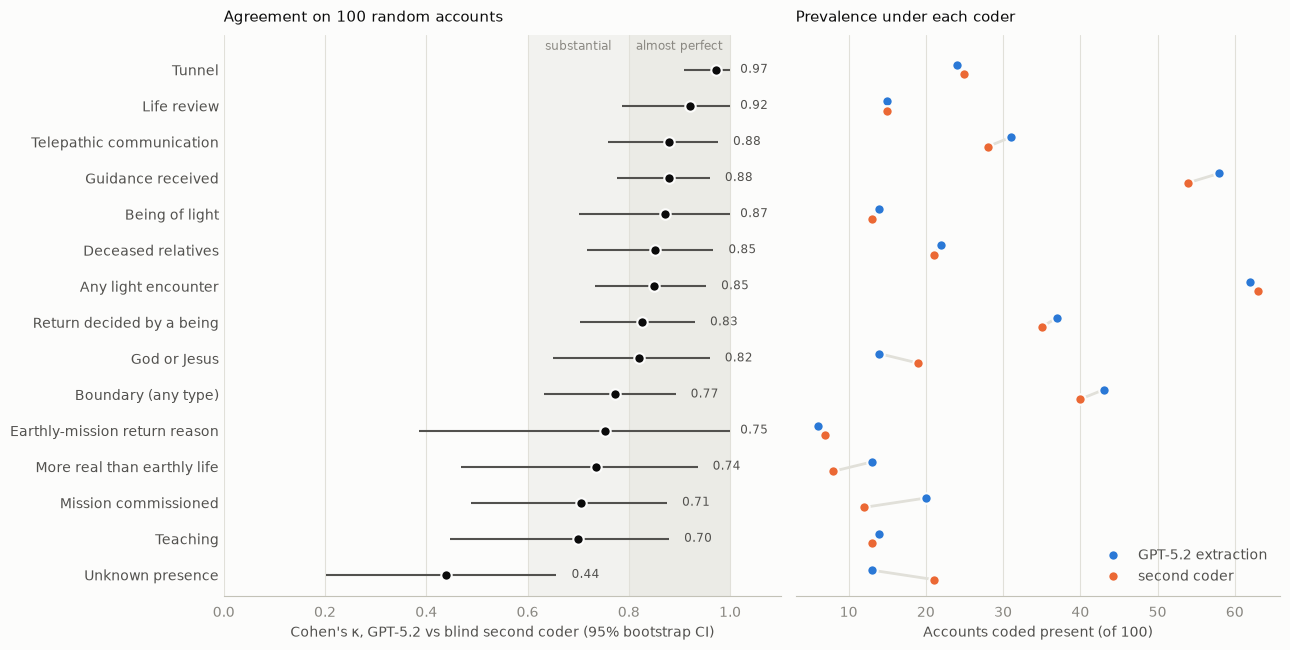

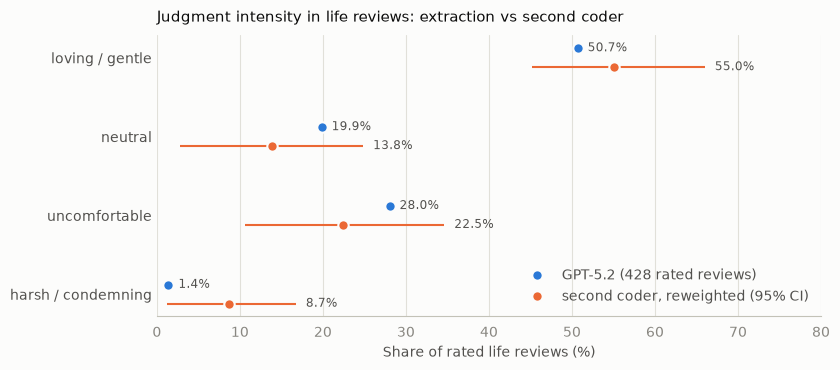

In [11]:
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SLOT = {"gpt": "#2a78d6", "coder": "#eb6834"}  # categorical slots 1-2, validated pair
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": AXIS, "axes.labelcolor": INK2,
                     "xtick.color": MUTED, "ytick.color": INK2, "text.color": INK, "axes.grid": False, "font.size": 10})

fields = [k for k in BINARY if "explicit only" not in k]
t = agree.loc[fields].sort_values("kappa")
fig, axes = plt.subplots(1, 2, figsize=(13, 6.6), gridspec_kw={"width_ratios": [1.15, 1]}, sharey=True)
y = np.arange(len(t))

ax = axes[0]
for x0, x1, lab in [(0.6, 0.8, "substantial"), (0.8, 1.0, "almost perfect")]:
    ax.axvspan(x0, x1, color=GRID, alpha=0.35 if lab == "substantial" else 0.6, lw=0, zorder=0)
    ax.text((x0 + x1) / 2, len(t) - 0.35, lab, ha="center", va="center", color=MUTED, fontsize=8.5)
ax.hlines(y, t["kappa lo"], t["kappa hi"], color=INK2, lw=1.5, zorder=2)
ax.plot(t["kappa"], y, "o", ms=7.5, color=INK, mec=SURFACE, mew=1.5, zorder=3)
for yi, k in zip(y, t["kappa"]):
    ax.text(min(t["kappa hi"].iloc[yi] + 0.03, 1.02), yi, f"{k:.2f}", va="center", fontsize=8.5, color=INK2)
ax.set_yticks(y, t.index)
ax.set_xlim(0, 1.1); ax.set_ylim(-0.6, len(t) - 0.05)
ax.set_xlabel("Cohen's κ, GPT-5.2 vs blind second coder (95% bootstrap CI)")
ax.xaxis.grid(True, color=GRID, lw=0.8); ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.set_title("Agreement on 100 random accounts", loc="left", color=INK, fontsize=11, pad=10)

ax = axes[1]
for yi, (gv, sv) in enumerate(zip(t["GPT +"], t["coder +"])):
    ax.plot([gv, sv], [yi + 0.13, yi - 0.13], color=GRID, lw=2, zorder=1)
ax.plot(t["GPT +"], y + 0.13, "o", ms=7.5, color=SLOT["gpt"], mec=SURFACE, mew=1.5, label="GPT-5.2 extraction", zorder=3)
ax.plot(t["coder +"], y - 0.13, "o", ms=7.5, color=SLOT["coder"], mec=SURFACE, mew=1.5, label="second coder", zorder=3)
ax.set_xlabel("Accounts coded present (of 100)")
ax.xaxis.grid(True, color=GRID, lw=0.8); ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.legend(loc="lower right", frameon=False, labelcolor=INK2)
ax.set_title("Prevalence under each coder", loc="left", color=INK, fontsize=11, pad=10)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "08_reliability_agreement.png", dpi=150, bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(8.5, 3.8))
labels = ["loving / gentle", "neutral", "uncomfortable", "harsh / condemning"]
keys = ["loving %", "neutral %", "uncomfortable %", "harsh %"]
yy = np.arange(len(keys))[::-1]
gv = [summarise(gpt_dist)[k] for k in keys]
sv = [point[k] for k in keys]
lo = [ci.loc[0.025, k] for k in keys]; hi = [ci.loc[0.975, k] for k in keys]
ax.hlines(yy - 0.12, lo, hi, color=SLOT["coder"], lw=1.5, zorder=2)
ax.plot(gv, yy + 0.12, "o", ms=7.5, color=SLOT["gpt"], mec=SURFACE, mew=1.5, label="GPT-5.2 (428 rated reviews)", zorder=3)
ax.plot(sv, yy - 0.12, "o", ms=7.5, color=SLOT["coder"], mec=SURFACE, mew=1.5, label="second coder, reweighted (95% CI)", zorder=3)
for yi, a_, b_, h_ in zip(yy, gv, sv, hi):
    ax.text(a_ + 1.2, yi + 0.12, f"{a_:.1f}%", va="center", fontsize=8.5, color=INK2)
    ax.text(h_ + 1.2, yi - 0.12, f"{b_:.1f}%", va="center", fontsize=8.5, color=INK2)
ax.set_yticks(yy, labels); ax.tick_params(axis="y", length=0)
ax.set_xlim(0, 80); ax.set_xlabel("Share of rated life reviews (%)")
ax.xaxis.grid(True, color=GRID, lw=0.8); ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.legend(loc="lower right", frameon=False, labelcolor=INK2)
ax.set_title("Judgment intensity in life reviews: extraction vs second coder", loc="left", color=INK, fontsize=11, pad=10)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "08_reliability_judgment.png", dpi=150, bbox_inches="tight"); plt.show()

## Part VII: Consequences for the reported findings

In [12]:
summary = {
    "set A accounts": len(set_a),
    "median kappa (binary)": round(agree.loc[[k for k in BINARY if "explicit only" not in k], "kappa"].median(), 2),
    "kappa range (binary)": (float(round(agree.loc[list(BINARY), "kappa"].min(), 2)), float(round(agree.loc[list(BINARY), "kappa"].max(), 2))),
    "judgment intensity weighted kappa": round(kw, 2),
    "GPT loving:harsh": round(summarise(gpt_dist)["loving:harsh"], 1),
    "second-coder loving:harsh": round(point["loving:harsh"], 1),
    "second-coder loving:harsh 95% CI": tuple(float(round(x, 1)) for x in ci["loving:harsh"]),
    "mission commissioned, GPT vs calibrated %": (float(round(mission_gpt, 1)), float(round(mission_cal, 1))),
    "near-duplicate pairs": len(pairs),
    "redundant records": redundant,
    "median test-retest kappa (identical / all flagged)": (float(round(retest.loc[list(FLAGS), "identical: kappa"].median(), 2)),
                                                            float(round(retest.loc[list(FLAGS), "all flagged: kappa"].median(), 2))),
}
for k, v in summary.items():
    print(f"{k:38s} {v}")

set A accounts                         100
median kappa (binary)                  0.83
kappa range (binary)                   (0.44, 0.97)
judgment intensity weighted kappa      0.74
GPT loving:harsh                       36.2
second-coder loving:harsh              6.4
second-coder loving:harsh 95% CI       (3.1, 43.9)
mission commissioned, GPT vs calibrated % (21.9, 14.8)
near-duplicate pairs                   125
redundant records                      121
median test-retest kappa (identical / all flagged) (0.88, 0.75)


### What the reliability study changes

Earlier reports listed the absence of human validation as a limitation. That framing implied that a human coder would supply a correct answer. A human coder would be a second reading with its own error, not ground truth. The real question is whether the measurement is reproducible. For most variables it is.

| Finding (notebook) | Fields it rests on | Reliability | Consequence |
|---|---|---|---|
| Being of Light: properties, communication, guidance (01) | light encounter, God/Jesus, telepathy, guidance, teaching | κ 0.70–0.88 | Holds; measurement adequate |
| "Unknown presence" as the majority identification (01) | `being_identifications` | κ 0.44 | Label depends on the codebook reading; carries no interpretive weight |
| Judgment character (01, 02) | `judgment_intensity` | weighted κ 0.74; harsh boundary unstable | "Rarely condemning, predominantly loving" holds; the 36:1 ratio is coder-dependent (6.4:1 under the second coder) |
| Sequence elements present (02) | tunnel, light, life review, boundary | κ 0.77–0.97 | Measurement adequate |
| Mission commissioning (03) | `mission_commissioned`, `return_reasons` | κ 0.71–0.75; liberal "implied" | Prevalence overstated (21.9% → 14.8%); the return-reason link holds under both coders |
| East–West comparisons (05) | deceased relatives, God/Jesus, boundary type | κ 0.85, 0.82; boundary type κ 0.34 | Relative and religious-figure counts adequate; boundary-type contrasts are not |
| Direct perception (06) | "more real" and perceptual markers | "more real" κ 0.74 (retest 0.58) | Prevalence approximate; other perceptual markers were not tested here |
| Entity function differentiation (07) | being groups, teaching, comfort, agency, verbal limit | κ 0.70–0.85; verbal limit depends on boundary type | Teaching and agency contrasts adequately measured; verbal-limit gatekeeping depends on an unstated precedence rule |

**Recommended schema fixes:**
1. Define `unknown_presence` against `other`.
2. Add a precedence rule for co-occurring boundary types.
3. Require a specific task for `mission_commissioned = implied`.
4. Anchor `harsh_condemning` with examples, especially self-condemnation in hellish reviews.
5. Collapse `no` and `not_mentioned` where the narrative cannot distinguish them.